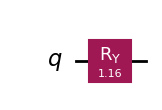

In [2]:
import numpy as np
from qiskit import QuantumCircuit

# chance the secondary ray hits the light source (simplified)
target_probability = 0.30

# Translate the probability into an angle
# a = sin^2(theta)
theta = np.arcsin(np.sqrt(target_probability))

# create the objective register (the ray tracer) 1 qubit only
A_operator = QuantumCircuit(1, name='A')

# We use an Ry gate to rotate the qubit from the default |0> state towards the |1> state
# represents the chance of 0 'missing' or 1 'hitting'
# Ry is the best choice because it moves across 0 and 1 state, but doesn't add imaginary #s
# Linear algebra uses Hilbert space, 0 and 1 are 90deg apart
# Bloch sphere are 180deg apart, so we have to stretch by 2*
A_operator.ry(2 * theta, 0)

A_operator.draw('mpl')

C:\Users\fatso\AppData\Local\Temp\ipykernel_14784\3019463762.py:10: DeprecationWarning: The class ``qiskit.circuit.library.grover_operator.GroverOperator`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use qiskit.circuit.library.grover_operator instead.
  Q_operator = GroverOperator(oracle=oracle, state_preparation=A_operator)


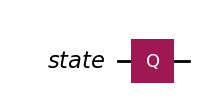

In [11]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import GroverOperator

# define the Oracle "hit state"
# apply a Z-gate to flip the phase of the |1> state
oracle = QuantumCircuit(1, name='Oracle')
oracle.z(0)

# We pass the Oracle first, and map our A_operator as the state_preparation
Q_operator = GroverOperator(oracle=oracle, state_preparation=A_operator)

display(Q_operator.draw('mpl'))

C:\Users\fatso\AppData\Local\Temp\ipykernel_14784\374842201.py:37: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  iqft = QFT(num_qubits=m, inverse=True, do_swaps=True).to_gate()


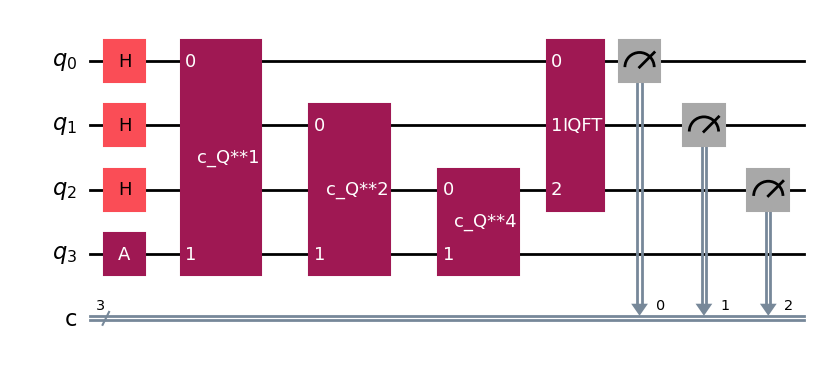

In [12]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import QFT

# 3 eval qubits
m = 3

# need 'm' evaluation qubits, + 1 objective qubit for our ray tracer
# also need 'm' classical bits to store our final measurement
qr = QuantumRegister(m + 1, 'q')    # 4 Qubits total (3 eval + 1 objective)
cr = ClassicalRegister(m, 'c')      # 3 Classical bits
qc = QuantumCircuit(qr, cr)
qr_eval = [0, 1, 2] # The first 3 qubits are our strobe lights
qr_obj = 3          # The 4th qubit is our ray tracer

# Apply the A operator to the objective qubit (step 2)
qc.append(A_operator, [qr_obj])

# Put the eval qubits into 50/50 superposition (step 3)
qc.h(qr_eval)

# apply grover (phase kickback) (Q) (step 4)
# We apply Q^1, Q^2, and Q^4, controlled by the evaluation qubits.
for k in range(m):
    # Calculate the power of 2: 2^0 = 1, 2^1 = 2, 2^2 = 4
    power = 2**k 
    
    # Create the controlled version of the Q operator for this power
    c_Q = Q_operator.power(power).control(1)
    
    # Apply it: The evaluation qubit 'k' acts as the control switch, 
    # and it targets the objective qubit 'qr_obj'
    qc.append(c_Q, [k, qr_obj])

# IQFT stage (step 5)
#  use Qiskit's built-in QFT library, set inverse=True
# and apply it to our evaluation qubits to decode the hidden phases.
iqft = QFT(num_qubits=m, inverse=True, do_swaps=True).to_gate()
iqft.name = "IQFT"
qc.append(iqft, qr_eval)

# measure (step 6)
# Measure the eval qubits and store the binary integer in the classical register
qc.measure(qr_eval, cr)

# Render the final master circuit
qc.draw('mpl')

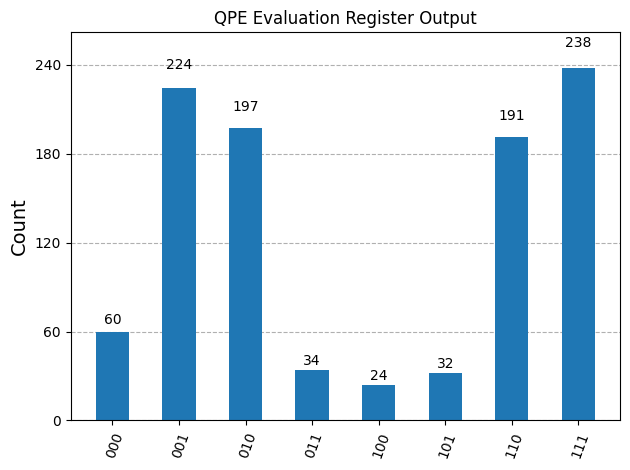

--------------------------------------------------
Target True Probability:      0.300
Most Frequent Measurement:    Integer 7 (Binary 111)
Calculated Estimated Angle:   2.7489 radians
Calculated Final Probability: 0.1464
--------------------------------------------------


In [13]:
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import numpy as np

# initialize local sim
simulator = AerSimulator()

# Transpile the circuit (Optimization step for the specific hardware/simulator)
compiled_circuit = transpile(qc, simulator)

# Execute the circuit 1000 times to build the measurement histogram
shots = 1000
job = simulator.run(compiled_circuit, shots=shots)
result = job.result()

counts = result.get_counts()

display(plot_histogram(counts, title="QPE Evaluation Register Output"))

# post processing

# Find the most frequently measured binary string
most_frequent_bitstring = max(counts, key=counts.get)

# Convert the bitstring to a base-10 integer (our 'y' value)
measured_integer = int(most_frequent_bitstring, 2)

# Apply the QAE math to extract the probability
m = 3  # Number of evaluation qubits
estimated_theta = (measured_integer * np.pi) / (2**m)
estimated_probability = np.sin(estimated_theta)**2

print("--------------------------------------------------")
print(f"Target True Probability:      0.300")
print(f"Most Frequent Measurement:    Integer {measured_integer} (Binary {most_frequent_bitstring})")
print(f"Calculated Estimated Angle:   {estimated_theta:.4f} radians")
print(f"Calculated Final Probability: {estimated_probability:.4f}")
print("--------------------------------------------------")

C:\Users\fatso\AppData\Local\Temp\ipykernel_33392\3482896484.py:24: DeprecationWarning: The class ``qiskit.circuit.library.grover_operator.GroverOperator`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use qiskit.circuit.library.grover_operator instead.
  Q_operator = GroverOperator(oracle=oracle, state_preparation=A_operator)
C:\Users\fatso\AppData\Local\Temp\ipykernel_33392\3482896484.py:51: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  iqft = QFT(num_qubits=m, inverse=True, do_swaps=True).to_gate()


Transpiling and simulating 7-qubit circuit. This may take a few seconds...

--- HIGH PRECISION RESULTS ---
Target True Probability:      0.3000
Most Frequent Measurement:    Integer 104 (Binary 1101000)
Calculated Estimated Angle:   2.5525 radians
Calculated Final Probability: 0.3087
------------------------------


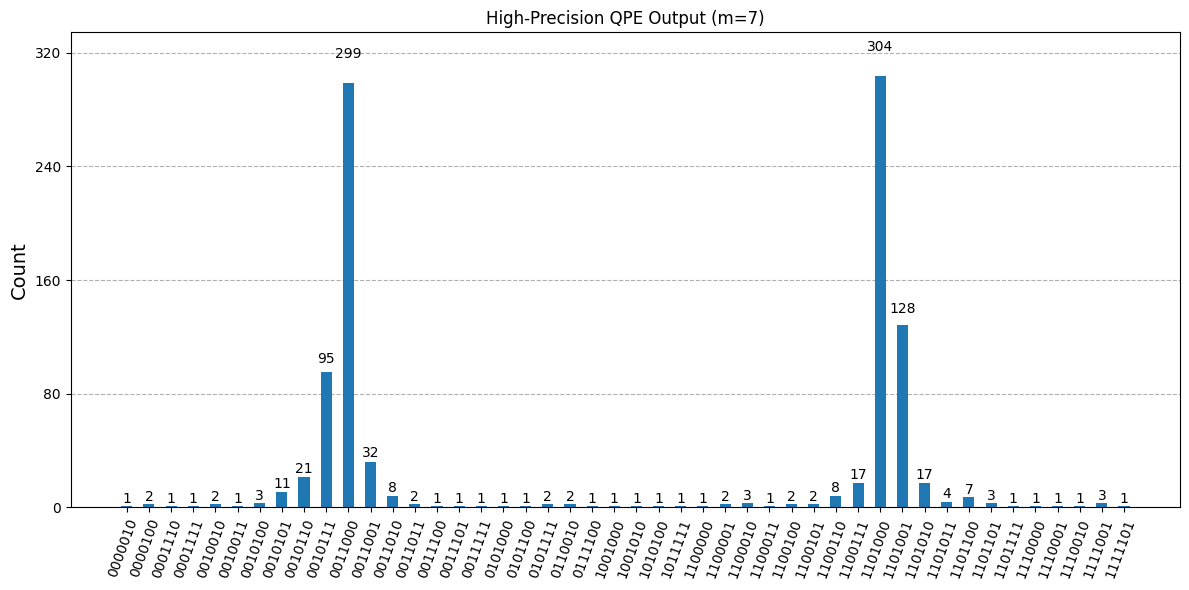

In [2]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import GroverOperator, QFT
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# ==========================================
# PART 1: REBUILD THE CORE OPERATORS
# ==========================================
target_probability = 0.30
theta = np.arcsin(np.sqrt(target_probability))

# 1. State Preparation (A)
A_operator = QuantumCircuit(1, name='A')
A_operator.ry(2 * theta, 0)

# 2. Oracle (Flagging the Hit State)
oracle = QuantumCircuit(1, name='Oracle')
oracle.z(0)

# 3. Grover Operator (Q)
Q_operator = GroverOperator(oracle=oracle, state_preparation=A_operator)

# ==========================================
# PART 2: BUILD THE HIGH-PRECISION PIPELINE
# ==========================================
m = 7  # 128 tick marks

qr = QuantumRegister(m + 1, 'q')
cr = ClassicalRegister(m, 'c')
qc_high_res = QuantumCircuit(qr, cr)

qr_eval = list(range(m))
qr_obj = m

# Step 1: State Preparation
qc_high_res.append(A_operator, [qr_obj])

# Step 2: Superposition of Evaluation Qubits
qc_high_res.h(qr_eval)

# Step 3: Controlled Grover Operations (Phase Kickback)
for k in range(m):
    power = 2**k 
    c_Q = Q_operator.power(power).control(1)
    qc_high_res.append(c_Q, [k, qr_obj])

# Step 4: Inverse QFT
iqft = QFT(num_qubits=m, inverse=True, do_swaps=True).to_gate()
iqft.name = "IQFT"
qc_high_res.append(iqft, qr_eval)

# Step 5: Measurement
qc_high_res.measure(qr_eval, cr)

# ==========================================
# PART 3: EXECUTE AND ANALYZE
# ==========================================
print(f"Transpiling and simulating {m}-qubit circuit. This may take a few seconds...")
simulator = AerSimulator()
compiled_circuit = transpile(qc_high_res, simulator)

shots = 1000
job = simulator.run(compiled_circuit, shots=shots)
result = job.result()
counts = result.get_counts()

# Calculate math on the highest peak
most_frequent_bitstring = max(counts, key=counts.get)
measured_integer = int(most_frequent_bitstring, 2)

estimated_theta = (measured_integer * np.pi) / (2**m)
estimated_probability = np.sin(estimated_theta)**2

print("\n--- HIGH PRECISION RESULTS ---")
print(f"Target True Probability:      0.3000")
print(f"Most Frequent Measurement:    Integer {measured_integer} (Binary {most_frequent_bitstring})")
print(f"Calculated Estimated Angle:   {estimated_theta:.4f} radians")
print(f"Calculated Final Probability: {estimated_probability:.4f}")
print("------------------------------")

# Display the high-resolution histogram
display(plot_histogram(counts, title="High-Precision QPE Output (m=7)", figsize=(12, 6)))